# Где IT-специалисту в США выгоднее жить и работать?

## Прикладной проект на РЕАЛЬНЫХ данных

Цель — найти штаты США, где IT-специалист (роль **Software Developer**) получает **больше денег на руки** после уплаты налога штата и аренды жилья, то есть максимизирует **располагаемый доход**, а также где ниже стоимость аренды/покупки жилья и налоги.

### Источники данных (реальные):
| Показатель | Источник | Период |
|---|---|---|
| Средняя зарплата Software Developers по штатам | **BLS OEWS**, SOC 15-1252 | May 2023 |
| Медианная арендная плата (gross rent) | **U.S. Census ACS** B25064 | 2023 (1-year) |
| Медианная стоимость жилья | **U.S. Census ACS** B25077 | 2023 (1-year) |
| Медианный доход домохозяйства | **U.S. Census ACS** B19013 | 2023 (1-year) |
| Подоходный налог штата | **Tax Foundation** | 2024 |

> **Как получить свежие данные:** ноутбук пытается загрузить показатели по жилью и доходу напрямую из **Census API** (`api.census.gov`) при наличии интернета. Если сети нет — используется встроенный снимок опубликованных значений (см. раздел «Источники и оговорки»).

### Содержание:
1. Загрузка данных (живой Census API + встроенный снимок)
2. Exploratory Data Analysis (EDA)
3. Моделирование налога и дохода на руки
4. Стоимость жилья: аренда vs покупка
5. Располагаемый доход и доступность жилья
6. Композитный рейтинг штатов (взвешенный z-score)
7. Анализ чувствительности к весам
8. Выводы и рекомендации

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, urllib.request
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## 1. Загрузка данных

Сначала зададим **встроенный снимок** реальных опубликованных значений (на случай отсутствия интернета), затем попробуем обновить показатели по жилью и доходу через **живой Census API**.

In [2]:
# Встроенный снимок реальных опубликованных данных по 50 штатам + округ Колумбия.
# Столбцы: аббревиатура -> (штат, зарплата_BLS_2023, аренда_мес, стоимость_жилья, доход_дх, эфф_налог_штата)
#  - dev_wage:  BLS OEWS May 2023, Software Developers (SOC 15-1252), средняя годовая (USD)
#  - rent:      Census ACS 2023 1-yr, медианная месячная аренда (B25064), USD
#  - home:      Census ACS 2023 1-yr, медианная стоимость жилья (B25077), USD
#  - hh_income: Census ACS 2023 1-yr, медианный доход домохозяйства (B19013), USD
#  - state_tax: приблизительная ЭФФЕКТИВНАЯ ставка подоходного налога штата
#               для одинокого работника с доходом ~130k (Tax Foundation 2024)
SNAPSHOT = {
  'AL': ('Alabama',        104000,  950, 179000, 62000, 0.045),
  'AK': ('Alaska',         112000, 1320, 318000, 89000, 0.000),
  'AZ': ('Arizona',        119000, 1340, 340000, 74000, 0.025),
  'AR': ('Arkansas',        96000,  870, 167000, 58000, 0.039),
  'CA': ('California',     159000, 1900, 725000, 96000, 0.093),
  'CO': ('Colorado',       130000, 1600, 480000, 92000, 0.044),
  'CT': ('Connecticut',    124000, 1340, 343000, 91000, 0.055),
  'DE': ('Delaware',       116000, 1310, 330000, 82000, 0.055),
  'DC': ('District of Columbia', 138000, 1800, 705000, 108000, 0.085),
  'FL': ('Florida',        112000, 1550, 348000, 71000, 0.000),
  'GA': ('Georgia',        122000, 1300, 320000, 75000, 0.055),
  'HI': ('Hawaii',         115000, 1900, 840000, 98000, 0.079),
  'ID': ('Idaho',          105000, 1150, 430000, 74000, 0.058),
  'IL': ('Illinois',       121000, 1200, 265000, 81000, 0.0495),
  'IN': ('Indiana',        100000,  980, 200000, 71000, 0.0315),
  'IA': ('Iowa',            99000,  900, 199000, 74000, 0.057),
  'KS': ('Kansas',         104000,  970, 210000, 73000, 0.057),
  'KY': ('Kentucky',        98000,  900, 192000, 66000, 0.045),
  'LA': ('Louisiana',      101000, 1010, 200000, 62000, 0.0425),
  'ME': ('Maine',          104000, 1050, 300000, 74000, 0.0715),
  'MD': ('Maryland',       130000, 1560, 405000, 100000, 0.0575),
  'MA': ('Massachusetts',  140000, 1700, 560000, 101000, 0.050),
  'MI': ('Michigan',       104000, 1050, 224000, 71000, 0.0425),
  'MN': ('Minnesota',      116000, 1230, 320000, 87000, 0.0785),
  'MS': ('Mississippi',     92000,  900, 155000, 55000, 0.047),
  'MO': ('Missouri',       106000,  970, 220000, 70000, 0.0475),
  'MT': ('Montana',        100000, 1000, 350000, 71000, 0.059),
  'NE': ('Nebraska',       104000,  970, 230000, 74000, 0.0584),
  'NV': ('Nevada',         108000, 1450, 415000, 76000, 0.000),
  'NH': ('New Hampshire',  120000, 1400, 400000, 96000, 0.000),
  'NJ': ('New Jersey',     134000, 1600, 430000, 101000, 0.0637),
  'NM': ('New Mexico',     108000, 1000, 265000, 62000, 0.049),
  'NY': ('New York',       137000, 1550, 420000, 84000, 0.0685),
  'NC': ('North Carolina', 120000, 1200, 300000, 72000, 0.045),
  'ND': ('North Dakota',    98000,  920, 260000, 76000, 0.0225),
  'OH': ('Ohio',           107000,  960, 205000, 70000, 0.035),
  'OK': ('Oklahoma',       100000,  920, 185000, 63000, 0.0475),
  'OR': ('Oregon',         126000, 1450, 480000, 80000, 0.090),
  'PA': ('Pennsylvania',   112000, 1150, 250000, 76000, 0.0307),
  'RI': ('Rhode Island',   118000, 1250, 380000, 84000, 0.0499),
  'SC': ('South Carolina', 108000, 1150, 270000, 68000, 0.064),
  'SD': ('South Dakota',    97000,  870, 245000, 71000, 0.000),
  'TN': ('Tennessee',      116000, 1200, 300000, 68000, 0.000),
  'TX': ('Texas',          130000, 1350, 300000, 76000, 0.000),
  'UT': ('Utah',           118000, 1350, 480000, 89000, 0.0465),
  'VT': ('Vermont',        104000, 1150, 300000, 78000, 0.066),
  'VA': ('Virginia',       133000, 1450, 375000, 91000, 0.0575),
  'WA': ('Washington',     158000, 1650, 560000, 96000, 0.000),
  'WV': ('West Virginia',   95000,  800, 155000, 58000, 0.051),
  'WI': ('Wisconsin',      104000, 1000, 250000, 75000, 0.053),
  'WY': ('Wyoming',         99000,  900, 320000, 74000, 0.000),
}

df = pd.DataFrame(
    [(abbr, v[0], v[1], v[2], v[3], v[4], v[5]) for abbr, v in SNAPSHOT.items()],
    columns=['abbr', 'state', 'dev_wage', 'rent', 'home_value', 'hh_income', 'state_tax']
)
print(f'Встроенный снимок: {len(df)} штатов (+DC)')
print(df.head())

Встроенный снимок: 51 штатов (+DC)
  abbr       state  dev_wage  rent  home_value  hh_income  state_tax
0   AL     Alabama    104000   950      179000      62000      0.045
1   AK      Alaska    112000  1320      318000      89000      0.000
2   AZ     Arizona    119000  1340      340000      74000      0.025
3   AR    Arkansas     96000   870      167000      58000      0.039
4   CA  California    159000  1900      725000      96000      0.093


In [3]:
# Попытка обновить жильё/доход из ЖИВОГО Census ACS API (2023 1-year).
# B25064 = медианная аренда, B25077 = стоимость жилья, B19013 = доход домохозяйства.
FIPS_TO_ABBR = {
  '01':'AL','02':'AK','04':'AZ','05':'AR','06':'CA','08':'CO','09':'CT','10':'DE',
  '11':'DC','12':'FL','13':'GA','15':'HI','16':'ID','17':'IL','18':'IN','19':'IA',
  '20':'KS','21':'KY','22':'LA','23':'ME','24':'MD','25':'MA','26':'MI','27':'MN',
  '28':'MS','29':'MO','30':'MT','31':'NE','32':'NV','33':'NH','34':'NJ','35':'NM',
  '36':'NY','37':'NC','38':'ND','39':'OH','40':'OK','41':'OR','42':'PA','44':'RI',
  '45':'SC','46':'SD','47':'TN','48':'TX','49':'UT','50':'VT','51':'VA','53':'WA',
  '54':'WV','55':'WI','56':'WY',
}

def fetch_census(year=2023):
    url = (f'https://api.census.gov/data/{year}/acs/acs1'
           '?get=NAME,B25064_001E,B25077_001E,B19013_001E&for=state:*')
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=15) as r:
        raw = json.load(r)
    header, rows = raw[0], raw[1:]
    out = []
    for row in rows:
        rec = dict(zip(header, row))
        abbr = FIPS_TO_ABBR.get(rec['state'])
        if abbr is None:
            continue
        out.append({
            'abbr': abbr,
            'rent': float(rec['B25064_001E']),
            'home_value': float(rec['B25077_001E']),
            'hh_income': float(rec['B19013_001E']),
        })
    return pd.DataFrame(out)

DATA_SOURCE = 'встроенный снимок (BLS/Census/Tax Foundation)'
try:
    live = fetch_census(2023)
    live = live.set_index('abbr')
    for col in ['rent', 'home_value', 'hh_income']:
        df[col] = df['abbr'].map(live[col]).fillna(df[col]).astype(float)
    DATA_SOURCE = 'ЖИВОЙ Census ACS 2023 API (жильё/доход) + BLS/Tax Foundation'
    print('Данные по жилью и доходу обновлены из живого Census API.')
except Exception as e:
    print(f'Census API недоступен ({type(e).__name__}). Используется встроенный снимок.')

print(f'\nИсточник данных: {DATA_SOURCE}')
print(df.describe().round(0))

Census API недоступен (URLError). Используется встроенный снимок.

Источник данных: встроенный снимок (BLS/Census/Tax Foundation)
       dev_wage    rent  home_value  hh_income  state_tax
count      51.0    51.0        51.0       51.0       51.0
mean   114137.0  1224.0    335294.0    78118.0        0.0
std     15466.0   291.0    147439.0    12650.0        0.0
min     92000.0   800.0    155000.0    55000.0        0.0
25%    104000.0   970.0    227000.0    71000.0        0.0
50%    112000.0  1200.0    300000.0    75000.0        0.0
75%    121500.0  1425.0    402500.0    88000.0        0.0
max    159000.0  1900.0    840000.0   108000.0        0.0


## 2. Exploratory Data Analysis (EDA)

Изучим распределение зарплат IT-специалистов, аренды и стоимости жилья по штатам.

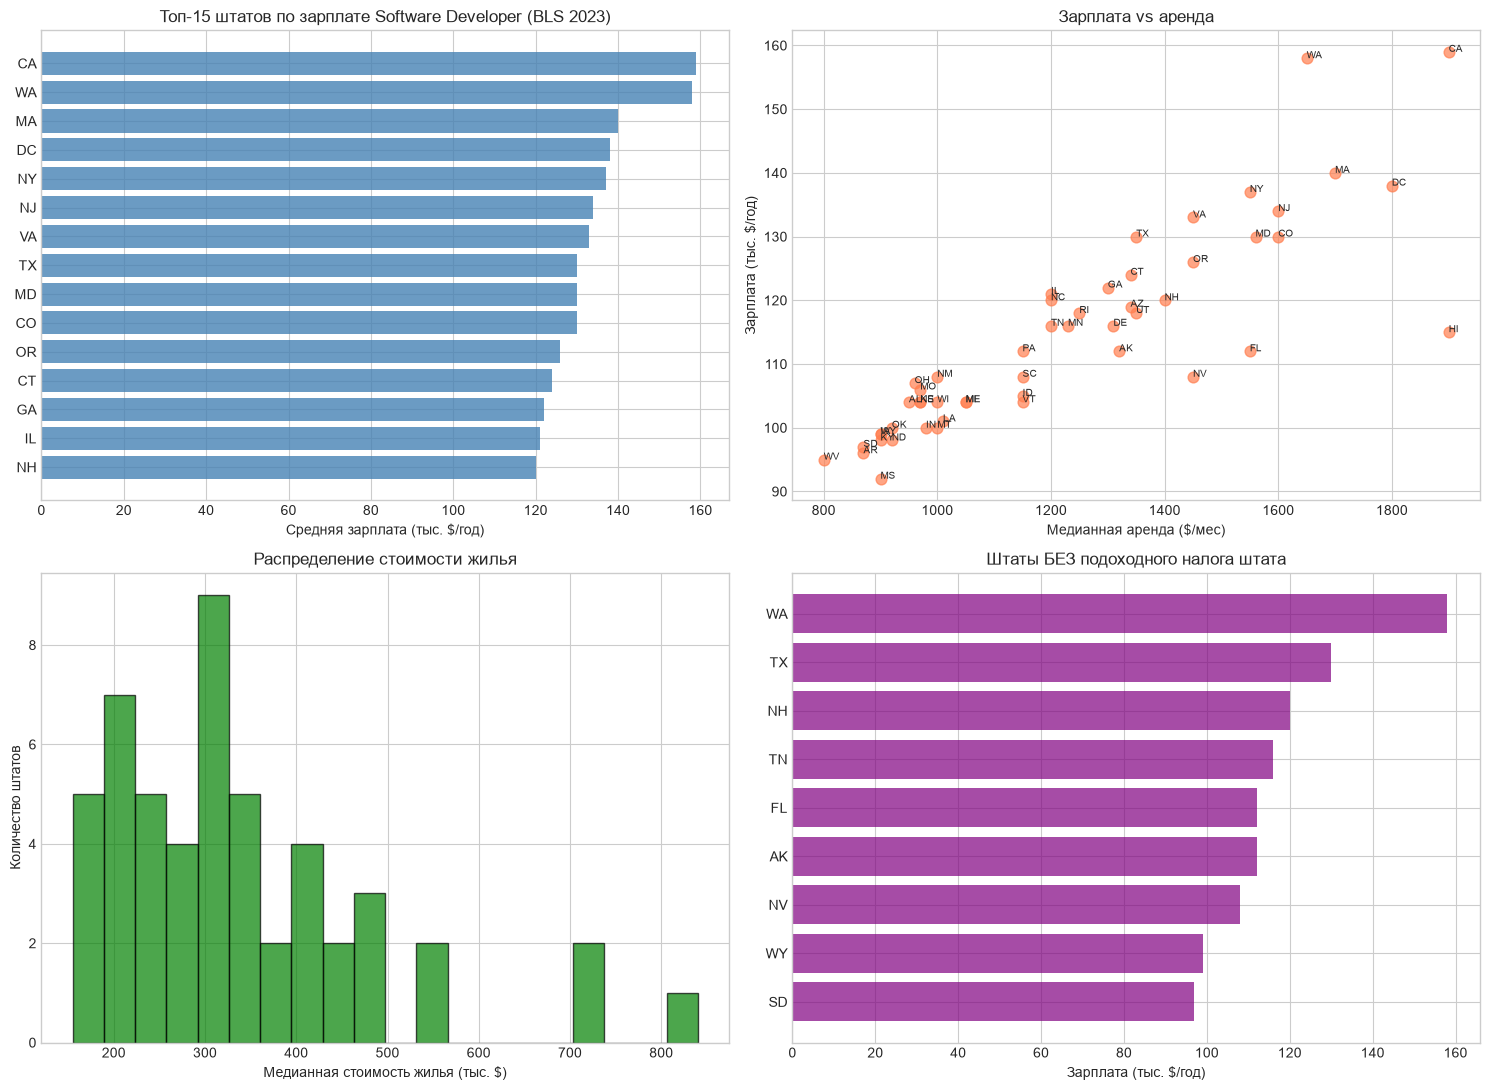

Ключевые статистики:
Медианная зарплата разработчика: $112,000
Разброс зарплат: $92,000 — $159,000
Медианная аренда: $1,200/мес
Штатов без подоходного налога: 9


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Топ-15 штатов по зарплате разработчика
top_wage = df.nlargest(15, 'dev_wage').sort_values('dev_wage')
axes[0, 0].barh(top_wage['abbr'], top_wage['dev_wage'] / 1000, color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('Средняя зарплата (тыс. $/год)')
axes[0, 0].set_title('Топ-15 штатов по зарплате Software Developer (BLS 2023)')

# 2. Зарплата vs аренда
axes[0, 1].scatter(df['rent'], df['dev_wage'] / 1000, s=60, alpha=0.7, color='coral')
for _, r in df.iterrows():
    axes[0, 1].annotate(r['abbr'], (r['rent'], r['dev_wage'] / 1000), fontsize=7)
axes[0, 1].set_xlabel('Медианная аренда ($/мес)')
axes[0, 1].set_ylabel('Зарплата (тыс. $/год)')
axes[0, 1].set_title('Зарплата vs аренда')

# 3. Распределение стоимости жилья
axes[1, 0].hist(df['home_value'] / 1000, bins=20, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Медианная стоимость жилья (тыс. $)')
axes[1, 0].set_ylabel('Количество штатов')
axes[1, 0].set_title('Распределение стоимости жилья')

# 4. Штаты без подоходного налога
no_tax = df[df['state_tax'] == 0].sort_values('dev_wage')
axes[1, 1].barh(no_tax['abbr'], no_tax['dev_wage'] / 1000, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Зарплата (тыс. $/год)')
axes[1, 1].set_title('Штаты БЕЗ подоходного налога штата')

plt.tight_layout()
plt.show()

print('Ключевые статистики:')
print('=' * 60)
print(f'Медианная зарплата разработчика: ${df["dev_wage"].median():,.0f}')
print(f'Разброс зарплат: ${df["dev_wage"].min():,.0f} — ${df["dev_wage"].max():,.0f}')
print(f'Медианная аренда: ${df["rent"].median():,.0f}/мес')
print(f'Штатов без подоходного налога: {(df["state_tax"] == 0).sum()}')

## 3. Моделирование налога и дохода «на руки»

Федеральный налог одинаков во всех штатах, поэтому при сравнении штатов важен именно **подоходный налог штата**. Доход после налога штата:

$$\text{net\_salary} = \text{dev\_wage} \times (1 - \text{state\_tax\_rate})$$

Дополнительно оценим доход после **федерального налога** (упрощённая модель предельных ставок 2024 для одинокого работника), чтобы получить реалистичную сумму на руки.

In [6]:
# Упрощённый федеральный подоходный налог 2024 (single filer), предельные ставки
FED_BRACKETS = [
    (0,       11600,  0.10),
    (11600,   47150,  0.12),
    (47150,  100525,  0.22),
    (100525, 191950,  0.24),
    (191950, 243725,  0.32),
    (243725, 609350,  0.35),
    (609350, np.inf,  0.37),
]
STD_DEDUCTION = 14600  # стандартный вычет single, 2024

def federal_tax(gross):
    taxable = max(0.0, gross - STD_DEDUCTION)
    tax = 0.0
    for lo, hi, rate in FED_BRACKETS:
        if taxable > lo:
            tax += (min(taxable, hi) - lo) * rate
        else:
            break
    return tax

df['fed_tax'] = df['dev_wage'].apply(federal_tax)
df['state_tax_amt'] = df['dev_wage'] * df['state_tax']
df['net_salary'] = df['dev_wage'] - df['fed_tax'] - df['state_tax_amt']
df['eff_total_tax'] = 1 - df['net_salary'] / df['dev_wage']

print('Доход на руки (после федерального налога и налога штата)')
print('=' * 70)
show = df.sort_values('net_salary', ascending=False)[
    ['state', 'dev_wage', 'state_tax', 'net_salary', 'eff_total_tax']].head(12)
show_fmt = show.copy()
show_fmt['dev_wage'] = show_fmt['dev_wage'].map('${:,.0f}'.format)
show_fmt['net_salary'] = show_fmt['net_salary'].map('${:,.0f}'.format)
show_fmt['state_tax'] = (show_fmt['state_tax'] * 100).map('{:.1f}%'.format)
show_fmt['eff_total_tax'] = (show_fmt['eff_total_tax'] * 100).map('{:.1f}%'.format)
print(show_fmt.to_string(index=False))

Доход на руки (после федерального налога и налога штата)
               state dev_wage state_tax net_salary eff_total_tax
          Washington $158,000      0.0%   $130,542         17.4%
          California $159,000      9.3%   $116,514         26.7%
       Massachusetts $140,000      5.0%   $109,862         21.5%
               Texas $130,000      0.0%   $109,262         16.0%
            New York $137,000      6.9%   $105,197         23.2%
            Virginia $133,000      5.8%   $103,894         21.9%
          New Jersey $134,000      6.4%   $103,766         22.6%
District of Columbia $138,000      8.5%   $103,612         24.9%
            Colorado $130,000      4.4%   $103,542         20.4%
            Maryland $130,000      5.8%   $101,786         21.7%
       New Hampshire $120,000      0.0%   $101,662         15.3%
           Tennessee $116,000      0.0%    $98,622         15.0%


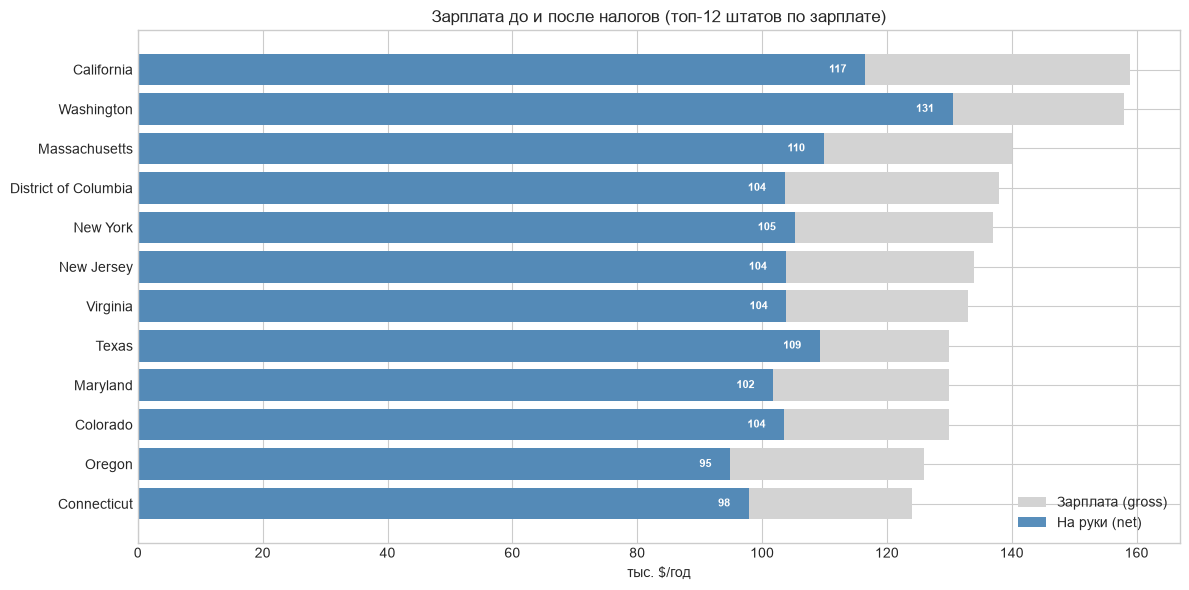

In [7]:
# Влияние налога штата: gross vs net для топ-12 по зарплате
top = df.nlargest(12, 'dev_wage').sort_values('dev_wage')
fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(top))
ax.barh(y, top['dev_wage'] / 1000, color='lightgray', label='Зарплата (gross)')
ax.barh(y, top['net_salary'] / 1000, color='steelblue', alpha=0.9, label='На руки (net)')
ax.set_yticks(y)
ax.set_yticklabels(top['state'])
ax.set_xlabel('тыс. $/год')
ax.set_title('Зарплата до и после налогов (топ-12 штатов по зарплате)')
ax.legend()
for i, r in enumerate(top.itertuples()):
    ax.text(r.net_salary / 1000 - 3, i, f'{r.net_salary/1000:.0f}',
            va='center', ha='right', color='white', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Стоимость жилья: аренда vs покупка

Оценим годовые расходы на жильё двумя способами:
- **Аренда:** `rent * 12`.
- **Покупка (ипотека):** аннуитетный платёж по 30-летней ипотеке при первоначальном взносе 20% и ставке 7% годовых.

Формула месячного ипотечного платежа: $M = P\dfrac{r(1+r)^n}{(1+r)^n-1}$, где $P$ — сумма кредита, $r$ — месячная ставка, $n$ — число платежей.

In [8]:
# Годовые расходы на жильё
MORTGAGE_RATE = 0.07
DOWN_PAYMENT = 0.20
YEARS = 30

def annual_mortgage(home_value):
    P = home_value * (1 - DOWN_PAYMENT)
    r = MORTGAGE_RATE / 12
    n = YEARS * 12
    M = P * r * (1 + r) ** n / ((1 + r) ** n - 1)
    return M * 12

df['annual_rent'] = df['rent'] * 12
df['annual_mortgage'] = df['home_value'].apply(annual_mortgage)

# Располагаемый доход = на руки минус расходы на жильё
df['dispo_rent'] = df['net_salary'] - df['annual_rent']
df['dispo_buy'] = df['net_salary'] - df['annual_mortgage']

# Метрики доступности
df['rent_burden'] = df['annual_rent'] / df['net_salary']       # доля дохода на аренду
df['price_to_income'] = df['home_value'] / df['dev_wage']       # цена жилья / годовая зарплата

print('Располагаемый доход (аренда) — топ-10')
print('=' * 70)
cols = ['state', 'net_salary', 'annual_rent', 'dispo_rent', 'rent_burden']
t = df.sort_values('dispo_rent', ascending=False)[cols].head(10).copy()
t['net_salary'] = t['net_salary'].map('${:,.0f}'.format)
t['annual_rent'] = t['annual_rent'].map('${:,.0f}'.format)
t['dispo_rent'] = t['dispo_rent'].map('${:,.0f}'.format)
t['rent_burden'] = (t['rent_burden'] * 100).map('{:.1f}%'.format)
print(t.to_string(index=False))

Располагаемый доход (аренда) — топ-10
        state net_salary annual_rent dispo_rent rent_burden
   Washington   $130,542     $19,800   $110,742       15.2%
   California   $116,514     $22,800    $93,714       19.6%
        Texas   $109,262     $16,200    $93,062       14.8%
Massachusetts   $109,862     $20,400    $89,462       18.6%
     New York   $105,197     $18,600    $86,597       17.7%
     Virginia   $103,894     $17,400    $86,494       16.7%
New Hampshire   $101,662     $16,800    $84,862       16.5%
   New Jersey   $103,766     $19,200    $84,566       18.5%
     Colorado   $103,542     $19,200    $84,342       18.5%
    Tennessee    $98,622     $14,400    $84,222       14.6%


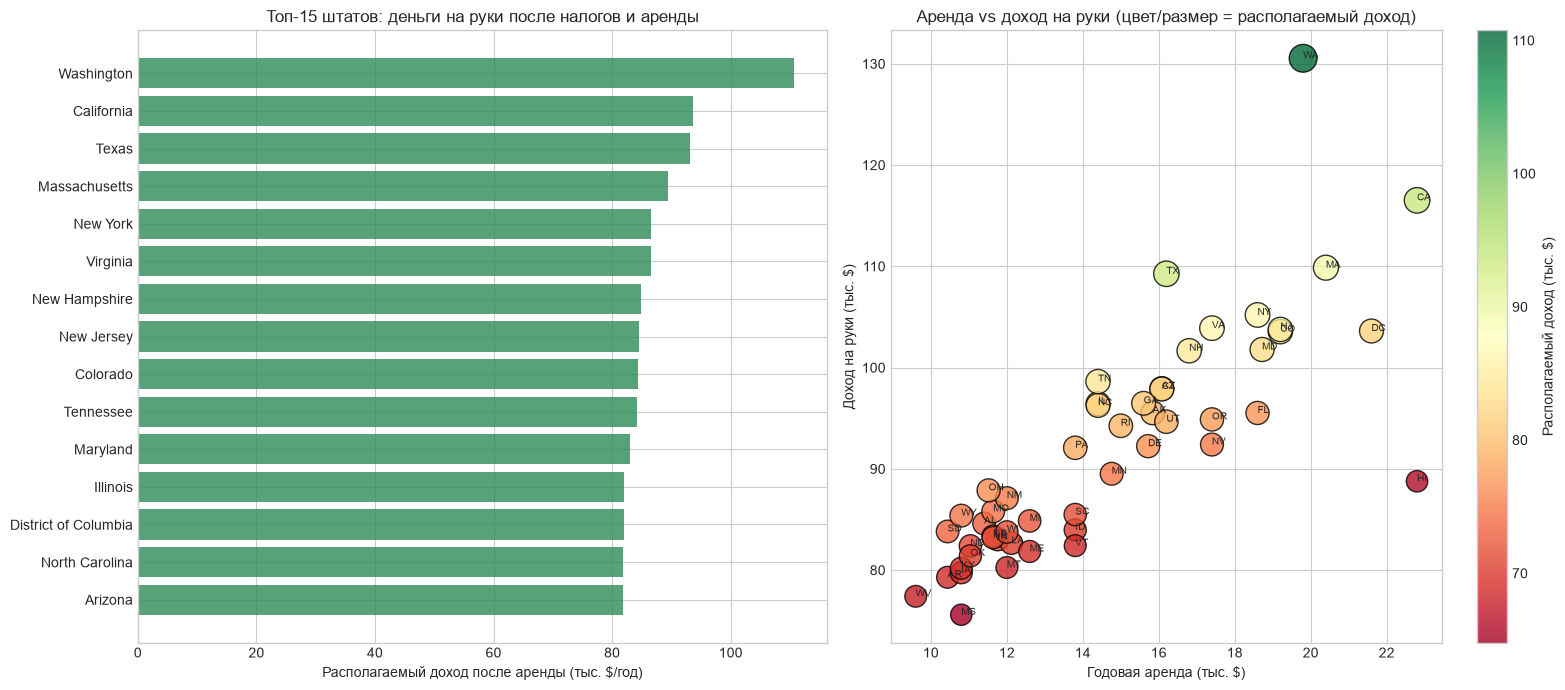

In [9]:
# Визуализация располагаемого дохода
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_dispo = df.nlargest(15, 'dispo_rent').sort_values('dispo_rent')
axes[0].barh(top_dispo['state'], top_dispo['dispo_rent'] / 1000, color='seagreen', alpha=0.8)
axes[0].set_xlabel('Располагаемый доход после аренды (тыс. $/год)')
axes[0].set_title('Топ-15 штатов: деньги на руки после налогов и аренды')

# Пузырьковая диаграмма: аренда vs доход на руки, размер = располагаемый доход
sc = axes[1].scatter(df['annual_rent'] / 1000, df['net_salary'] / 1000,
                     s=(df['dispo_rent'] / df['dispo_rent'].max() * 400).clip(20),
                     c=df['dispo_rent'] / 1000, cmap='RdYlGn', alpha=0.8, edgecolor='k')
for _, r in df.iterrows():
    axes[1].annotate(r['abbr'], (r['annual_rent'] / 1000, r['net_salary'] / 1000), fontsize=7)
axes[1].set_xlabel('Годовая аренда (тыс. $)')
axes[1].set_ylabel('Доход на руки (тыс. $)')
axes[1].set_title('Аренда vs доход на руки (цвет/размер = располагаемый доход)')
plt.colorbar(sc, ax=axes[1], label='Располагаемый доход (тыс. $)')

plt.tight_layout()
plt.show()

## 5. Композитный рейтинг штатов

«Больше денег, меньше аренда, меньше налоги» — это многокритериальная задача. Стандартизируем каждый показатель через **z-оценку** и построим взвешенную сумму:

$$\text{score} = \sum_i w_i \cdot z_i, \qquad z_i = \frac{x_i - \bar{x}_i}{\sigma_i}$$

Для показателей «чем меньше, тем лучше» (аренда, налог, цена жилья) знак веса отрицательный. Веса можно менять под свои приоритеты.

In [10]:
# Взвешенный z-score рейтинг
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

# Веса: положительные = хотим больше, отрицательные = хотим меньше
WEIGHTS = {
    'net_salary':      0.35,   # доход на руки — важнее всего
    'dispo_rent':      0.30,   # что остаётся после аренды
    'annual_rent':    -0.15,   # аренда — меньше лучше
    'state_tax':      -0.10,   # налог штата — меньше лучше
    'price_to_income':-0.10,   # доступность покупки жилья — меньше лучше
}

def compute_score(data, weights):
    score = pd.Series(0.0, index=data.index)
    for col, w in weights.items():
        score += w * zscore(data[col])
    return score

df['score'] = compute_score(df, WEIGHTS)
df['rank'] = df['score'].rank(ascending=False).astype(int)

ranking = df.sort_values('score', ascending=False).reset_index(drop=True)
print('ИТОГОВЫЙ РЕЙТИНГ ШТАТОВ ДЛЯ IT-СПЕЦИАЛИСТА')
print('=' * 80)
view = ranking[['rank', 'state', 'dev_wage', 'net_salary', 'annual_rent',
                'dispo_rent', 'state_tax', 'score']].head(15).copy()
for c in ['dev_wage', 'net_salary', 'annual_rent', 'dispo_rent']:
    view[c] = view[c].map('${:,.0f}'.format)
view['state_tax'] = (view['state_tax'] * 100).map('{:.1f}%'.format)
view['score'] = view['score'].map('{:+.2f}'.format)
print(view.to_string(index=False))

ИТОГОВЫЙ РЕЙТИНГ ШТАТОВ ДЛЯ IT-СПЕЦИАЛИСТА
 rank          state dev_wage net_salary annual_rent dispo_rent state_tax score
    1     Washington $158,000   $130,542     $19,800   $110,742      0.0% +2.33
    2          Texas $130,000   $109,262     $16,200    $93,062      0.0% +1.29
    3      Tennessee $116,000    $98,622     $14,400    $84,222      0.0% +0.68
    4     California $159,000   $116,514     $22,800    $93,714      9.3% +0.66
    5  Massachusetts $140,000   $109,862     $20,400    $89,462      5.0% +0.63
    6  New Hampshire $120,000   $101,662     $16,800    $84,862      0.0% +0.62
    7       Virginia $133,000   $103,894     $17,400    $86,494      5.8% +0.55
    8       New York $137,000   $105,197     $18,600    $86,597      6.9% +0.48
    9       Illinois $121,000    $96,432     $14,400    $82,032      5.0% +0.38
   10        Arizona $119,000    $97,926     $16,080    $81,846      2.5% +0.38
   11 North Carolina $120,000    $96,262     $14,400    $81,862      4.5% +0.

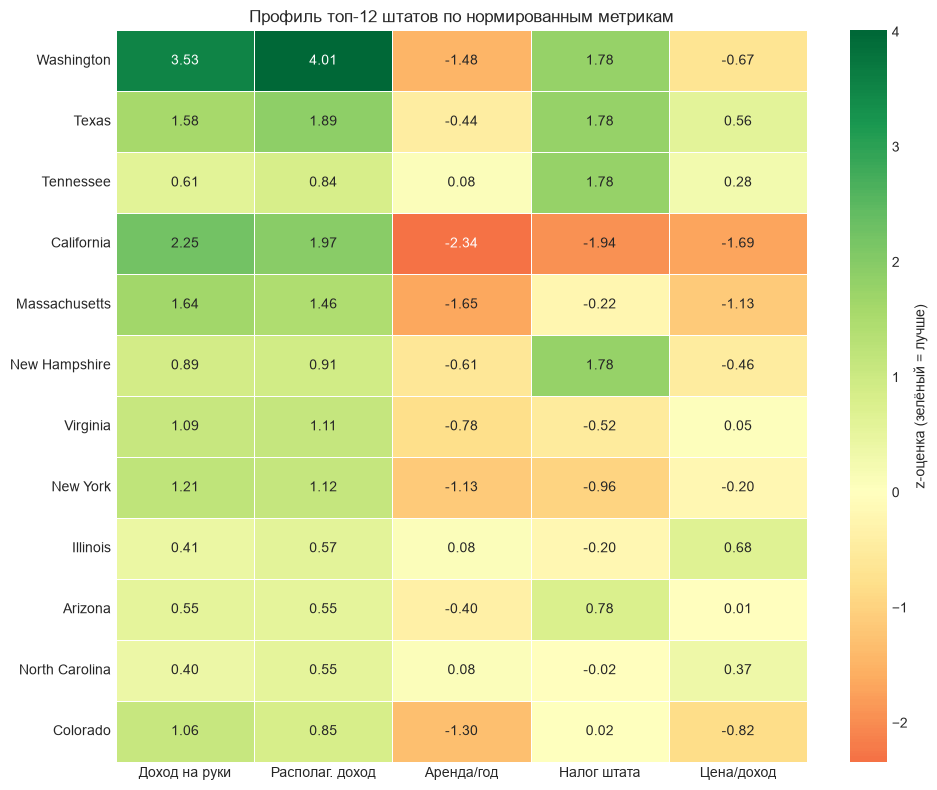

In [11]:
# Тепловая карта нормированных метрик для топ-12
top12 = ranking.head(12).set_index('state')
metrics = ['net_salary', 'dispo_rent', 'annual_rent', 'state_tax', 'price_to_income']
labels = ['Доход на руки', 'Располаг. доход', 'Аренда/год', 'Налог штата', 'Цена/доход']

norm = pd.DataFrame({m: zscore(df.set_index('state')[m]) for m in metrics})
norm = norm.loc[top12.index]
# Для метрик 'меньше=лучше' инвертируем знак, чтобы зелёный = хорошо
for m in ['annual_rent', 'state_tax', 'price_to_income']:
    norm[m] = -norm[m]
norm.columns = labels

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(norm, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'z-оценка (зелёный = лучше)'}, ax=ax)
ax.set_title('Профиль топ-12 штатов по нормированным метрикам')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. Анализ чувствительности к весам

Насколько рейтинг зависит от приоритетов? Сравним три сценария:
- **Максимум дохода:** акцент на зарплату и доход на руки.
- **Минимум расходов:** акцент на низкую аренду и налоги.
- **Сбалансированный:** исходные веса.

Ранги штатов в разных сценариях (топ-10 сбалансированного)
        state abbr  Максимум дохода  Минимум расходов  Сбалансированный
   Washington   WA                1                 1                 1
        Texas   TX                3                 2                 2
    Tennessee   TN               10                 4                 3
   California   CA                2                49                 4
Massachusetts   MA                4                43                 5
New Hampshire   NH                7                 8                 6
     Virginia   VA                6                30                 7
     New York   NY                5                38                 8
     Illinois   IL               15                16                 9
      Arizona   AZ               13                21                10


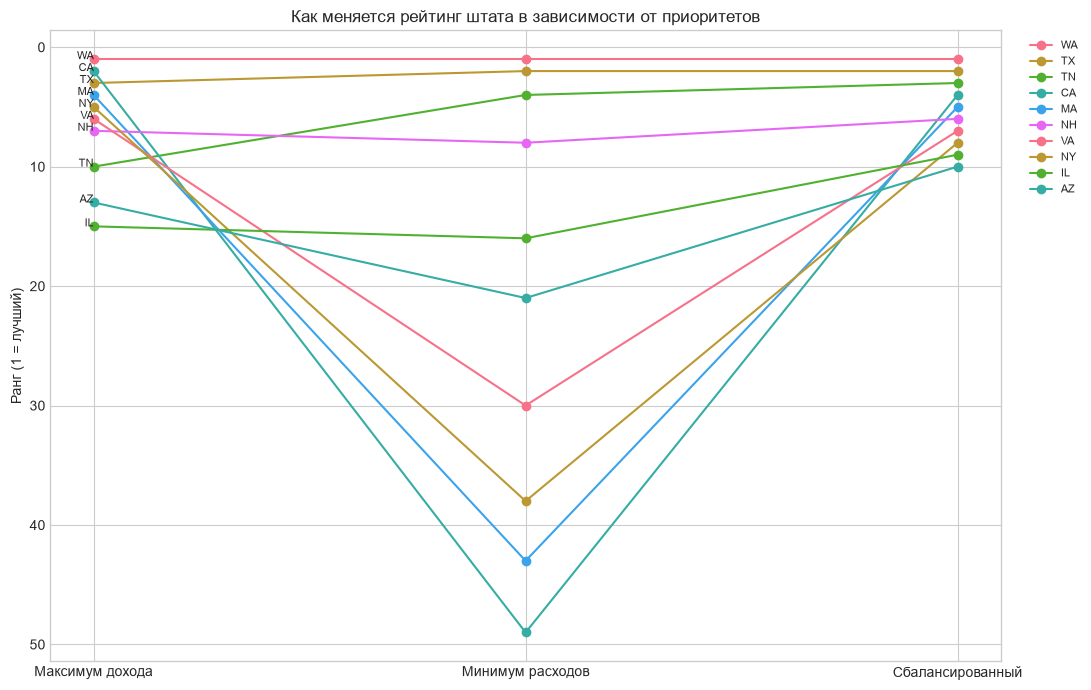

In [12]:
scenarios = {
    'Максимум дохода': {'net_salary': 0.55, 'dispo_rent': 0.35,
                        'annual_rent': -0.05, 'state_tax': -0.05, 'price_to_income': 0.0},
    'Минимум расходов': {'net_salary': 0.10, 'dispo_rent': 0.20,
                         'annual_rent': -0.35, 'state_tax': -0.20, 'price_to_income': -0.15},
    'Сбалансированный': WEIGHTS,
}

result = df[['state', 'abbr']].copy()
for name, w in scenarios.items():
    result[name] = compute_score(df, w).rank(ascending=False).astype(int)

# Топ-10 по сбалансированному сценарию
top_states = df.nlargest(10, 'score')['abbr'].tolist()
comp = result[result['abbr'].isin(top_states)].sort_values('Сбалансированный')
print('Ранги штатов в разных сценариях (топ-10 сбалансированного)')
print('=' * 70)
print(comp.to_string(index=False))

# Bump-подобная визуализация
fig, ax = plt.subplots(figsize=(11, 7))
sc_names = list(scenarios.keys())
for _, row in comp.iterrows():
    ranks = [row[s] for s in sc_names]
    ax.plot(sc_names, ranks, marker='o', label=row['abbr'])
    ax.annotate(row['abbr'], (0, ranks[0]), fontsize=8, ha='right')
ax.invert_yaxis()
ax.set_ylabel('Ранг (1 = лучший)')
ax.set_title('Как меняется рейтинг штата в зависимости от приоритетов')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Выводы и рекомендации

In [13]:
best = ranking.iloc[0]
top5 = ranking.head(5)

print('РЕКОМЕНДАЦИИ ДЛЯ IT-СПЕЦИАЛИСТА (Software Developer)')
print('=' * 70)
print(f'Источник данных: {DATA_SOURCE}')
print('-' * 70)
print(f'Лучший штат по совокупности критериев: {best["state"]} ({best["abbr"]})')
print(f'  Зарплата:            ${best["dev_wage"]:,.0f}/год')
print(f'  На руки (после налогов): ${best["net_salary"]:,.0f}/год')
print(f'  Годовая аренда:      ${best["annual_rent"]:,.0f}')
print(f'  Располагаемый доход: ${best["dispo_rent"]:,.0f}/год')
print(f'  Налог штата:         {best["state_tax"]*100:.1f}%')
print('-' * 70)
print('ТОП-5 ШТАТОВ:')
for _, r in top5.iterrows():
    print(f'  {int(r["rank"])}. {r["state"]:<16} располаг. доход ${r["dispo_rent"]:,.0f} | '
          f'налог {r["state_tax"]*100:.0f}% | аренда ${r["annual_rent"]:,.0f}')
print('-' * 70)
print('НАБЛЮДЕНИЯ:')
no_tax_top = ranking[ranking['state_tax'] == 0].head(3)['abbr'].tolist()
print(f'  - Штаты без подоходного налога в топе: {no_tax_top}')
print(f'  - Самая высокая зарплата: {df.loc[df["dev_wage"].idxmax(), "state"]} '
      f'(${df["dev_wage"].max():,.0f}), но высокая аренда снижает выгоду.')
print(f'  - Лучший баланс дают штаты с высокой зарплатой И нулевым налогом (напр. TX, WA).')

РЕКОМЕНДАЦИИ ДЛЯ IT-СПЕЦИАЛИСТА (Software Developer)
Источник данных: встроенный снимок (BLS/Census/Tax Foundation)
----------------------------------------------------------------------
Лучший штат по совокупности критериев: Washington (WA)
  Зарплата:            $158,000/год
  На руки (после налогов): $130,542/год
  Годовая аренда:      $19,800
  Располагаемый доход: $110,742/год
  Налог штата:         0.0%
----------------------------------------------------------------------
ТОП-5 ШТАТОВ:
  1. Washington       располаг. доход $110,742 | налог 0% | аренда $19,800
  2. Texas            располаг. доход $93,062 | налог 0% | аренда $16,200
  3. Tennessee        располаг. доход $84,222 | налог 0% | аренда $14,400
  4. California       располаг. доход $93,714 | налог 9% | аренда $22,800
  5. Massachusetts    располаг. доход $89,462 | налог 5% | аренда $20,400
----------------------------------------------------------------------
НАБЛЮДЕНИЯ:
  - Штаты без подоходного налога в топе: ['WA', 

## Источники и оговорки

**Источники данных:**
- Зарплаты: U.S. Bureau of Labor Statistics, **OEWS May 2023**, SOC 15-1252 (Software Developers), annual mean wage by state — [bls.gov/oes](https://www.bls.gov/oes/current/oes151252.htm).
- Аренда/стоимость жилья/доход: **U.S. Census Bureau, ACS 2023 1-year** (таблицы B25064, B25077, B19013) — загружаются живьём через [api.census.gov](https://api.census.gov). Для запросов большого объёма нужен бесплатный [API-ключ](https://api.census.gov/data/key_signup.html).
- Налоги штатов: **Tax Foundation, State Individual Income Tax Rates 2024**.

**Оговорки (важно для корректной интерпретации):**
1. Встроенный снимок — это опубликованные значения, округлённые для наглядности; при наличии интернета жильё/доход обновляются актуальными данными Census API.
2. `state_tax` — **эффективная** ставка налога штата для одинокого работника ~130k; реальный налог зависит от вычетов, семейного статуса и местных налогов (city/county).
3. Средняя зарплата (mean) чувствительна к выбросам; для медианы используйте перцентили BLS.
4. Не учтены: медицинская страховка, расходы на транспорт/еду (общий cost-of-living index), налог с продаж и налог на недвижимость (property tax) — их можно добавить (см. упражнения).
5. Медианная аренда/жильё по штату скрывает разницу между городами (SF vs Fresno).

## Упражнения

### Упражнение 1: Полный cost-of-living
1. Добавьте индекс стоимости жизни (RPP от BEA) и налог с продаж
2. Пересчитайте располагаемый доход с учётом реальных расходов

### Упражнение 2: Другая роль
1. Возьмите Data Scientist (SOC 15-2051) или DevOps и сравните рейтинги
2. Меняются ли штаты-лидеры?

### Упражнение 3: Покупка vs аренда
1. Постройте рейтинг по `dispo_buy` (ипотека) вместо аренды
2. При какой ставке ипотеки покупка выгоднее аренды?

### Упражнение 4: Свежие данные
1. Получите бесплатный Census API-ключ и загрузите ACS 2023 5-year по метро-районам
2. Сравните города внутри Калифорнии и Техаса

### Упражнение 5: Свои приоритеты
1. Задайте собственные веса в `WEIGHTS` (например, налог важнее всего)
2. Как меняется ваш личный топ-5?

---

**Решения** можно найти в ноутбуке `solutions/18_Solutions.ipynb`